# RTS-GMLC UC Instance — EDA Interactive Notebook

This notebook provides interactive exploration and visualization of pglib-uc **RTS-GMLC** unit commitment instance data using pandas, matplotlib, and itables.

**To switch instances:** change `INSTANCE_FILE` in the next cell and re-run all cells.

Available instances in the `rts_gmlc/` collection (12 total):
- Monthly dates Jan–Dec 2020 (`2020-01-27`, `2020-02-09`, …)
- See also: `ferc/` → `PG_Lib_FERC_Instance/` notebook | `ca/` → California instances

In [11]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from itables import show
import itables.options as opt
opt.lengthMenu = [10, 25, 50, 100]

In [12]:
# ── Instance Selection ───────────────────────────────────────────────────────────────────
# Point INSTANCE_DIR at any pglib-uc collection folder.
# Set INSTANCE_FILE to the specific JSON file within that folder.
# Re-run all cells after changing either variable.

INSTANCE_DIR  = r'C:\gitrepos\power-grid-lib\pglib-uc\\rts_gmlc'
INSTANCE_FILE = '2020-01-27.json'   # ← change this to select a different instance

# List available instances so you can see what’s there
available = sorted(f for f in os.listdir(INSTANCE_DIR) if f.endswith('.json'))
print(f"Available instances in '{os.path.basename(INSTANCE_DIR)}':")
for f in available:
    marker = '  ← selected' if f == INSTANCE_FILE else ''
    print(f'  {f}{marker}')

JSON_PATH      = os.path.join(INSTANCE_DIR, INSTANCE_FILE)
THERMAL_PATH   = 'thermal_generators.json'
RENEWABLE_PATH = 'renewable_generators.json'
DEMAND_PATH    = 'demand.json'
print(f'Loading: {JSON_PATH}')

Available instances in 'rts_gmlc':
  2020-01-27.json  ← selected
  2020-02-09.json
  2020-03-05.json
  2020-04-03.json
  2020-05-05.json
  2020-06-09.json
  2020-07-06.json
  2020-08-12.json
  2020-09-20.json
  2020-10-27.json
  2020-11-25.json
  2020-12-23.json
Loading: C:\gitrepos\power-grid-lib\pglib-uc\\rts_gmlc\2020-01-27.json


In [13]:
# Load JSON Data
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

# Load main data if available
try:
    data = load_json(JSON_PATH)
except Exception as e:
    print(f'Could not load main JSON: {e}')
    data = None

In [14]:
# Extract and Save Sub-Objects
sub_keys = ['demand', 'thermal_generators', 'renewable_generators', 'hydro_generators', 'buses', 'branches', 'time', 'reserve', 'commitment']
def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)
if data:
    for key in sub_keys:
        if key in data:
            save_json(data[key], f'{key}.json')
            print(f'Saved {key}.json')

Saved demand.json
Saved thermal_generators.json
Saved renewable_generators.json


In [15]:
# Analyze Generators with itables
with open(THERMAL_PATH) as f:
    thermal_data = json.load(f)
thermal_df = pd.DataFrame.from_dict(thermal_data, orient='index')

# Columns to extract scalar values from
extract_cols = [
    'power_output_maximum',
    'power_output_minimum',
    'ramp_up_limit',
    'ramp_down_limit',
    'ramp_startup_limit',
    'ramp_shutdown_limit',
    'time_up_minimum',
    'time_down_minimum',
    'power_output_t0',
    'unit_on_t0',
    'time_up_t0',
    'time_down_t0'
]

def extract_scalar(x):
    if isinstance(x, (list, tuple)) and len(x) > 0:
        if all(isinstance(i, (int, float)) for i in x):
            return max(x)
        elif isinstance(x[0], (int, float)):
            return x[0]
        else:
            return float('nan')
    elif isinstance(x, (int, float)):
        return x
    else:
        try:
            return float(x) # type: ignore
        except:
            return float('nan')

for col in extract_cols:
    if col in thermal_df.columns:
        thermal_df[col] = thermal_df[col].apply(extract_scalar).astype('float64')

# Convert any remaining object columns with nested structures to strings
for col in thermal_df.columns:
    if thermal_df[col].dtype == object:
        thermal_df[col] = thermal_df[col].astype(str)

# reset_index makes the generator name a regular column so DataTables
# column numbering is unambiguous (no hidden index offset)
show(thermal_df.reset_index(), maxBytes=0)

Loading ITables v2.7.1 from the internet... (need help?)


In [16]:
# Plot Generator Size Distributions
size_cols = ['Pmax', 'capacity', 'max_output']
for col in size_cols:
    if col in thermal_df.columns:
        plt.figure(figsize=(8, 5))
        thermal_df[col].astype(float).hist(bins=30)
        plt.title(f'Generator {col} Distribution')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

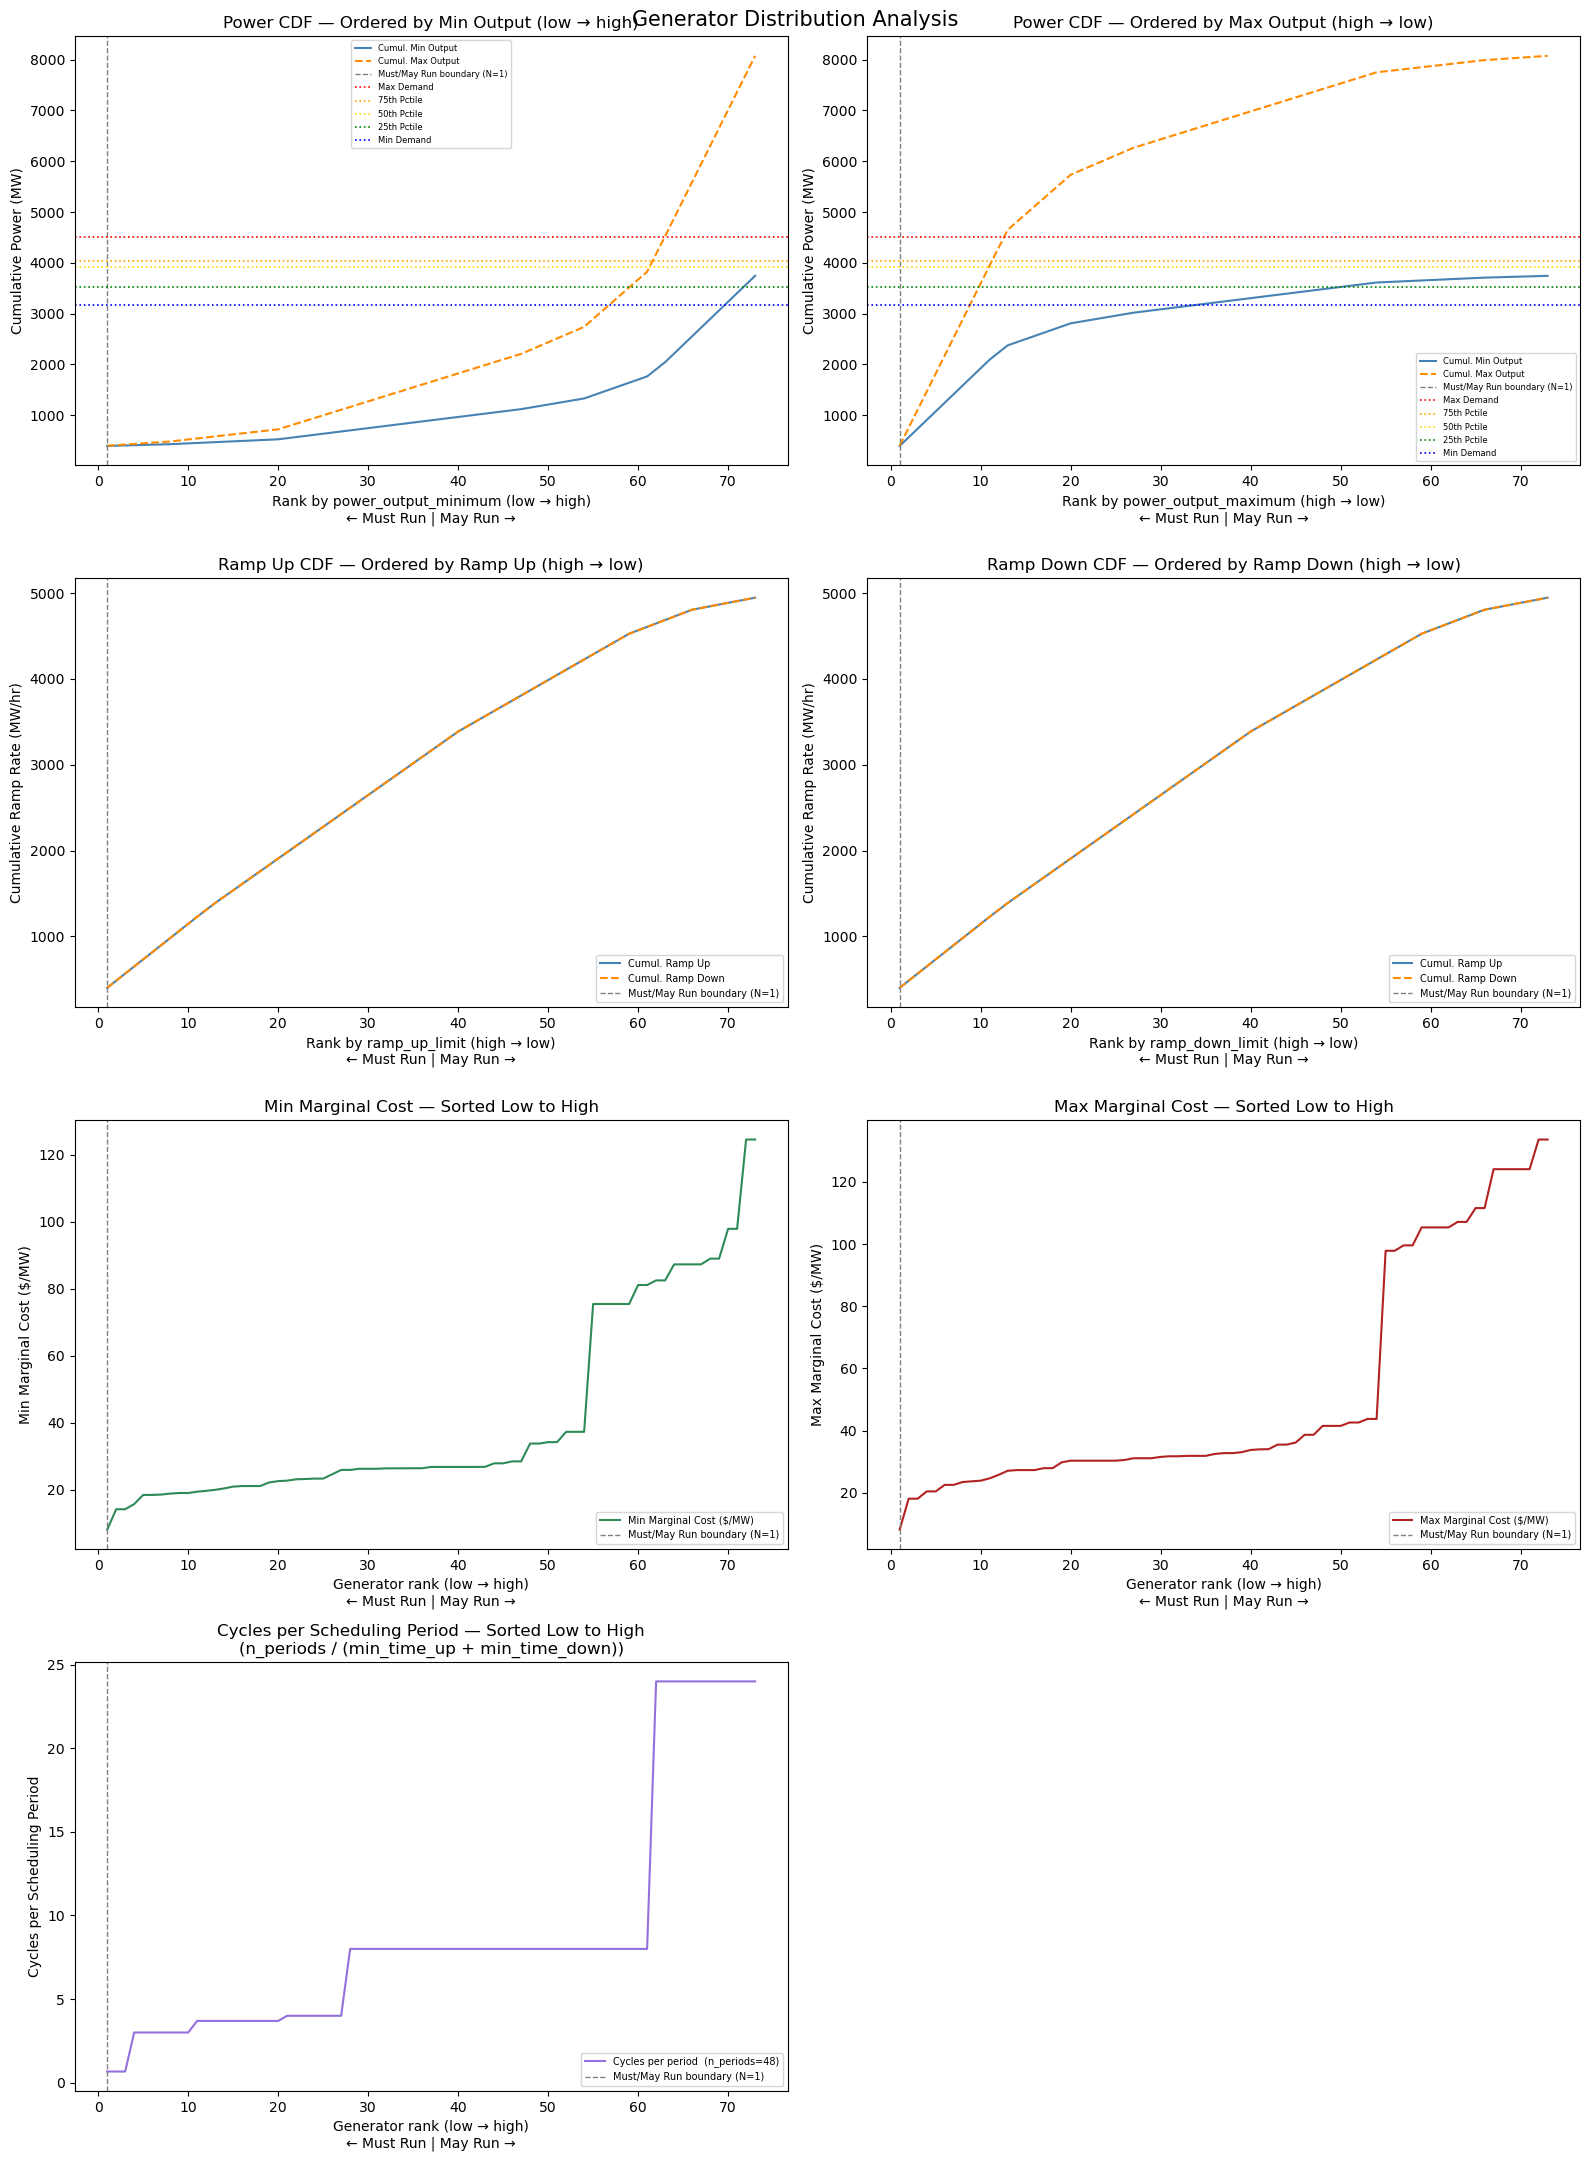

In [17]:
# Generator Distribution Analysis — Power CDFs, Ramp CDFs, Marginal Cost PDFs, Cycles per Period
import numpy as np

# ── Demand reference lines ────────────────────────────────────────────────────
with open(DEMAND_PATH) as f:
    demand_vals = json.load(f)
n_periods = len(demand_vals)
demand_series = pd.Series(demand_vals)
demand_refs = {
    'Max Demand':   (demand_series.max(),           'red'),
    '75th Pctile':  (demand_series.quantile(0.75),  'orange'),
    '50th Pctile':  (demand_series.quantile(0.50),  'gold'),
    '25th Pctile':  (demand_series.quantile(0.25),  'green'),
    'Min Demand':   (demand_series.min(),            'blue'),
}

# ── Marginal cost ranges ──────────────────────────────────────────────────────
with open(THERMAL_PATH) as f:
    _thermal_raw = json.load(f)

def _get_mc_range(gen_data):
    pts = gen_data.get('piecewise_production', [])
    mcs = [
        (pts[i+1]['cost'] - pts[i]['cost']) / (pts[i+1]['mw'] - pts[i]['mw'])
        for i in range(len(pts) - 1)
        if pts[i+1]['mw'] - pts[i]['mw'] > 0
    ]
    return (min(mcs), max(mcs)) if mcs else (np.nan, np.nan)

_mc_rows = []
for gen_name, gen_data in _thermal_raw.items():
    mc_min, mc_max = _get_mc_range(gen_data)
    _mc_rows.append({'mc_min': mc_min, 'mc_max': mc_max, 'must_run': gen_data.get('must_run', 0)})
mc_pdf_df = pd.DataFrame(_mc_rows).dropna()

# ── Cycles per scheduling period ──────────────────────────────────────────────
cycles_df = thermal_df[['time_up_minimum', 'time_down_minimum', 'must_run']].copy()
cycles_df['cycle_time'] = cycles_df['time_up_minimum'] + cycles_df['time_down_minimum']
cycles_df['cycles_per_period'] = n_periods / cycles_df['cycle_time'].replace(0, np.nan)
cycles_df = cycles_df.dropna(subset=['cycles_per_period'])

# ── Layout: 4 rows × 2 columns ───────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle('Generator Distribution Analysis', fontsize=15)

# ── Row 0: Power Output CDFs ──────────────────────────────────────────────────
def plot_power_cdf(ax, sort_col, ascending, title):
    must = thermal_df[thermal_df['must_run'] == 1].sort_values(sort_col, ascending=ascending)
    may  = thermal_df[thermal_df['must_run'] == 0].sort_values(sort_col, ascending=ascending)
    df_s = pd.concat([must, may]).reset_index(drop=True)
    x = range(1, len(df_s) + 1)
    ax.plot(x, df_s['power_output_minimum'].cumsum(), color='steelblue',  linestyle='-',  label='Cumul. Min Output')
    ax.plot(x, df_s['power_output_maximum'].cumsum(), color='darkorange', linestyle='--', label='Cumul. Max Output')
    ax.axvline(x=len(must), color='gray', linestyle='--', linewidth=1,
               label=f'Must/May Run boundary (N={len(must)})')
    for label, (val, color) in demand_refs.items():
        ax.axhline(y=val, color=color, linestyle=':', linewidth=1.2, label=label)
    direction = 'low → high' if ascending else 'high → low'
    ax.set_title(title)
    ax.set_xlabel(f'Rank by {sort_col} ({direction})\n← Must Run | May Run →')
    ax.set_ylabel('Cumulative Power (MW)')
    ax.legend(fontsize=6)

plot_power_cdf(axes[0, 0], 'power_output_minimum', ascending=True,
               title='Power CDF — Ordered by Min Output (low → high)')
plot_power_cdf(axes[0, 1], 'power_output_maximum', ascending=False,
               title='Power CDF — Ordered by Max Output (high → low)')

# ── Row 1: Ramp Rate CDFs ─────────────────────────────────────────────────────
def plot_ramp_cdf(ax, sort_col, title):
    must = thermal_df[thermal_df['must_run'] == 1].sort_values(sort_col, ascending=False)
    may  = thermal_df[thermal_df['must_run'] == 0].sort_values(sort_col, ascending=False)
    df_s = pd.concat([must, may]).reset_index(drop=True)
    x = range(1, len(df_s) + 1)
    ax.plot(x, df_s['ramp_up_limit'].cumsum(),   color='steelblue',  linestyle='-',  label='Cumul. Ramp Up')
    ax.plot(x, df_s['ramp_down_limit'].cumsum(), color='darkorange', linestyle='--', label='Cumul. Ramp Down')
    ax.axvline(x=len(must), color='gray', linestyle='--', linewidth=1,
               label=f'Must/May Run boundary (N={len(must)})')
    ax.set_title(title)
    ax.set_xlabel(f'Rank by {sort_col} (high → low)\n← Must Run | May Run →')
    ax.set_ylabel('Cumulative Ramp Rate (MW/hr)')
    ax.legend(fontsize=7)

plot_ramp_cdf(axes[1, 0], 'ramp_up_limit',   title='Ramp Up CDF — Ordered by Ramp Up (high → low)')
plot_ramp_cdf(axes[1, 1], 'ramp_down_limit', title='Ramp Down CDF — Ordered by Ramp Down (high → low)')

# ── Row 2: Marginal Cost sorted value plots ───────────────────────────────────
def plot_mc_sorted(ax, col, color, title, y_label):
    must = mc_pdf_df[mc_pdf_df['must_run'] == 1].sort_values(col).reset_index(drop=True)
    may  = mc_pdf_df[mc_pdf_df['must_run'] == 0].sort_values(col).reset_index(drop=True)
    df_s = pd.concat([must, may]).reset_index(drop=True)
    x = range(1, len(df_s) + 1)
    ax.plot(x, df_s[col], color=color, linewidth=1.5, label=y_label)
    ax.axvline(x=len(must), color='gray', linestyle='--', linewidth=1,
               label=f'Must/May Run boundary (N={len(must)})')
    ax.set_title(title)
    ax.set_xlabel('Generator rank (low → high)\n← Must Run | May Run →')
    ax.set_ylabel(y_label)
    ax.legend(fontsize=7)

plot_mc_sorted(axes[2, 0], 'mc_min', 'seagreen',
               title='Min Marginal Cost — Sorted Low to High',
               y_label='Min Marginal Cost ($/MW)')
plot_mc_sorted(axes[2, 1], 'mc_max', 'firebrick',
               title='Max Marginal Cost — Sorted Low to High',
               y_label='Max Marginal Cost ($/MW)')

# ── Row 3: Cycles per scheduling period ───────────────────────────────────────
must_c = cycles_df[cycles_df['must_run'] == 1].sort_values('cycles_per_period').reset_index(drop=True)
may_c  = cycles_df[cycles_df['must_run'] == 0].sort_values('cycles_per_period').reset_index(drop=True)
df_cyc = pd.concat([must_c, may_c]).reset_index(drop=True)
x_cyc  = range(1, len(df_cyc) + 1)

axes[3, 0].plot(x_cyc, df_cyc['cycles_per_period'], color='mediumpurple', linewidth=1.5,
                label=f'Cycles per period  (n_periods={n_periods})')
axes[3, 0].axvline(x=len(must_c), color='gray', linestyle='--', linewidth=1,
                   label=f'Must/May Run boundary (N={len(must_c)})')
axes[3, 0].set_title('Cycles per Scheduling Period — Sorted Low to High\n'
                      '(n_periods / (min_time_up + min_time_down))')
axes[3, 0].set_xlabel('Generator rank (low → high)\n← Must Run | May Run →')
axes[3, 0].set_ylabel('Cycles per Scheduling Period')
axes[3, 0].legend(fontsize=7)

axes[3, 1].set_visible(False)

plt.tight_layout()
plt.show()

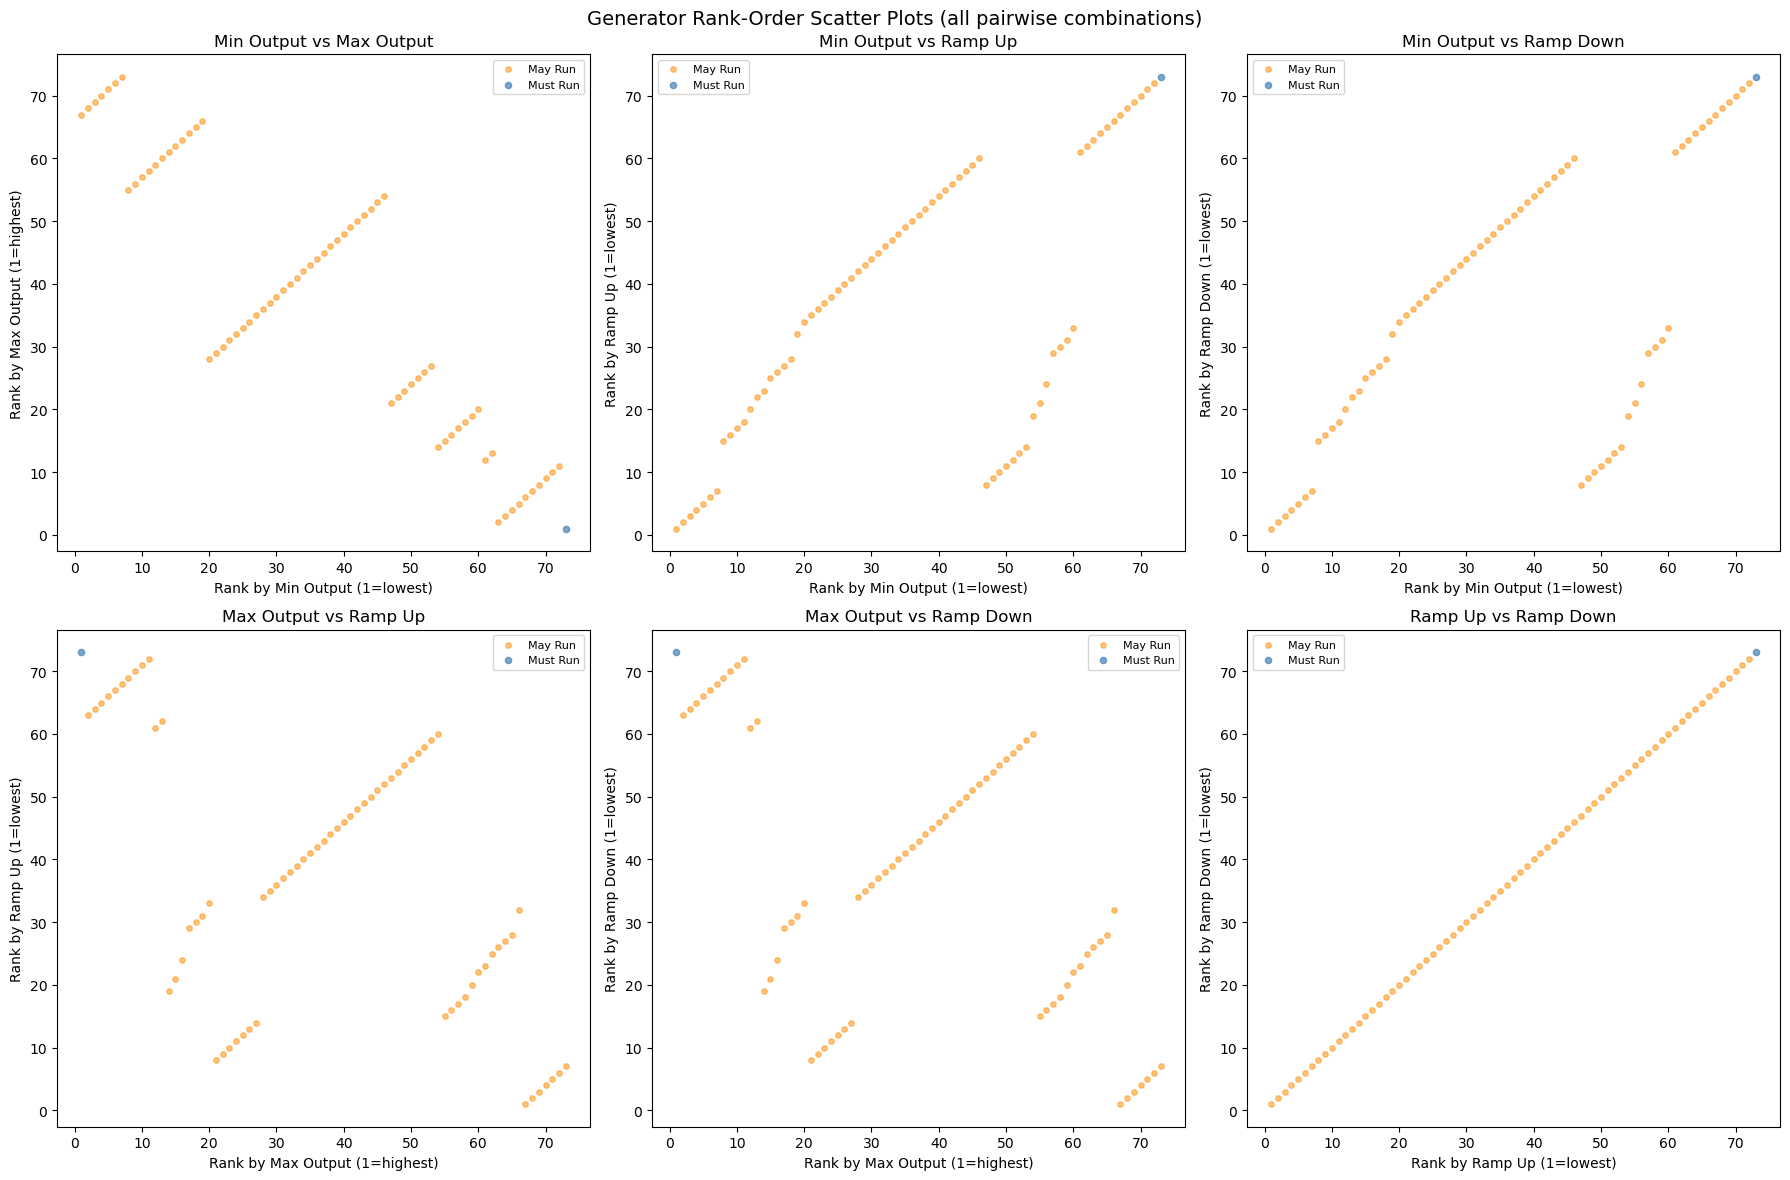

In [18]:
# All 6 rank-order scatter plots (every pairwise combination)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Generator Rank-Order Scatter Plots (all pairwise combinations)', fontsize=14)

# Assign ranks across the full dataset
thermal_ranked = thermal_df.copy()
thermal_ranked['rank_min_output'] = thermal_ranked['power_output_minimum'].rank(method='first', ascending=True)
thermal_ranked['rank_max_output'] = thermal_ranked['power_output_maximum'].rank(method='first', ascending=False)
thermal_ranked['rank_ramp_up']    = thermal_ranked['ramp_up_limit'].rank(method='first', ascending=True)
thermal_ranked['rank_ramp_down']  = thermal_ranked['ramp_down_limit'].rank(method='first', ascending=True)

must = thermal_ranked[thermal_ranked['must_run'] == 1]
may  = thermal_ranked[thermal_ranked['must_run'] == 0]

combos = [
    (axes[0, 0], 'rank_min_output', 'rank_max_output',  'Min Output (1=lowest)',  'Max Output (1=highest)', 'Min Output vs Max Output'),
    (axes[0, 1], 'rank_min_output', 'rank_ramp_up',     'Min Output (1=lowest)',  'Ramp Up (1=lowest)',     'Min Output vs Ramp Up'),
    (axes[0, 2], 'rank_min_output', 'rank_ramp_down',   'Min Output (1=lowest)',  'Ramp Down (1=lowest)',   'Min Output vs Ramp Down'),
    (axes[1, 0], 'rank_max_output', 'rank_ramp_up',     'Max Output (1=highest)', 'Ramp Up (1=lowest)',     'Max Output vs Ramp Up'),
    (axes[1, 1], 'rank_max_output', 'rank_ramp_down',   'Max Output (1=highest)', 'Ramp Down (1=lowest)',   'Max Output vs Ramp Down'),
    (axes[1, 2], 'rank_ramp_up',    'rank_ramp_down',   'Ramp Up (1=lowest)',     'Ramp Down (1=lowest)',   'Ramp Up vs Ramp Down'),
]

for ax, x_col, y_col, x_label, y_label, title in combos:
    ax.scatter(may[x_col],  may[y_col],  alpha=0.5, s=15, color='darkorange', label='May Run')
    ax.scatter(must[x_col], must[y_col], alpha=0.7, s=20, color='steelblue',  label='Must Run')
    ax.set_xlabel(f'Rank by {x_label}')
    ax.set_ylabel(f'Rank by {y_label}')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# Generator Rank Table — all computed rankings in one interactive itable
import numpy as np
from itables import show

with open(THERMAL_PATH) as f:
    _rank_raw = json.load(f)

# ── Build base scalar columns ─────────────────────────────────────────────────
_rank_rows = []
for gen_name, gen_data in _rank_raw.items():
    pts = gen_data.get('piecewise_production', [])
    mcs = [
        (pts[i+1]['cost'] - pts[i]['cost']) / (pts[i+1]['mw'] - pts[i]['mw'])
        for i in range(len(pts) - 1)
        if pts[i+1]['mw'] - pts[i]['mw'] > 0
    ]
    mc_min = min(mcs) if mcs else np.nan
    mc_max = max(mcs) if mcs else np.nan

    tup_min = gen_data.get('time_up_minimum', np.nan)
    tdn_min = gen_data.get('time_down_minimum', np.nan)
    if isinstance(tup_min, list): tup_min = tup_min[0] if tup_min else np.nan
    if isinstance(tdn_min, list): tdn_min = tdn_min[0] if tdn_min else np.nan
    cycle = (tup_min + tdn_min) if not (np.isnan(tup_min) or np.isnan(tdn_min)) else np.nan

    _rank_rows.append({
        'generator':            gen_name,
        'must_run':             int(gen_data.get('must_run', 0)),
        'power_output_minimum': float(gen_data.get('power_output_minimum', np.nan)),
        'power_output_maximum': float(gen_data.get('power_output_maximum', np.nan)),
        'ramp_up_limit':        float(gen_data.get('ramp_up_limit', np.nan)),
        'ramp_down_limit':      float(gen_data.get('ramp_down_limit', np.nan)),
        'mc_min':               mc_min,
        'mc_max':               mc_max,
        'cycle_time':           cycle,
    })

ranks_df = pd.DataFrame(_rank_rows).set_index('generator')

# Theoretical max cycles in the planning period = n_periods / cycle_time
# (n_periods defined earlier when demand data was loaded)
ranks_df['cycles_per_period'] = n_periods / ranks_df['cycle_time'].replace(0, np.nan)

# ── Assign ranks ──────────────────────────────────────────────────────────────
# Convention: rank 1 = the generator that comes first in the described ordering
ranks_df['rank_min_output_low_high']      = ranks_df['power_output_minimum'].rank(method='min', ascending=True).astype('Int64')
ranks_df['rank_max_output_high_low']      = ranks_df['power_output_maximum'].rank(method='min', ascending=False).astype('Int64')
ranks_df['rank_ramp_up_low_high']         = ranks_df['ramp_up_limit'].rank(method='min', ascending=True).astype('Int64')
ranks_df['rank_ramp_down_low_high']       = ranks_df['ramp_down_limit'].rank(method='min', ascending=True).astype('Int64')
ranks_df['rank_mc_min_low_high']          = ranks_df['mc_min'].rank(method='min', ascending=True, na_option='bottom').astype('Int64')
ranks_df['rank_mc_max_low_high']          = ranks_df['mc_max'].rank(method='min', ascending=True, na_option='bottom').astype('Int64')
# Rank by cycles per period: rank 1 = fewest possible cycles (least flexible)
ranks_df['rank_cycles_per_period_low_high'] = ranks_df['cycles_per_period'].rank(method='min', ascending=True, na_option='bottom').astype('Int64')

# ── Select and format display columns ────────────────────────────────────────
display_df = ranks_df[[
    'must_run',
    'power_output_minimum', 'rank_min_output_low_high',
    'power_output_maximum', 'rank_max_output_high_low',
    'ramp_up_limit',        'rank_ramp_up_low_high',
    'ramp_down_limit',      'rank_ramp_down_low_high',
    'mc_min',               'rank_mc_min_low_high',
    'mc_max',               'rank_mc_max_low_high',
    'cycles_per_period',    'rank_cycles_per_period_low_high',
]].rename(columns={
    'must_run':                       'Must Run',
    'power_output_minimum':           'Pmin (MW)',
    'rank_min_output_low_high':       'Rank: Pmin ↑',
    'power_output_maximum':           'Pmax (MW)',
    'rank_max_output_high_low':       'Rank: Pmax ↓',
    'ramp_up_limit':                  'Ramp Up (MW/hr)',
    'rank_ramp_up_low_high':          'Rank: Ramp Up ↑',
    'ramp_down_limit':                'Ramp Down (MW/hr)',
    'rank_ramp_down_low_high':        'Rank: Ramp Down ↑',
    'mc_min':                         'MC Min ($/MW)',
    'rank_mc_min_low_high':           'Rank: MC Min ↑',
    'mc_max':                         'MC Max ($/MW)',
    'rank_mc_max_low_high':           'Rank: MC Max ↑',
    'cycles_per_period':              'Cycles/Period',
    'rank_cycles_per_period_low_high':'Rank: Cycles/Period ↑',
})

show(
    display_df.reset_index().rename(columns={'generator': 'Generator'}),
    caption="Generator Rankings — ↑ = rank 1 is lowest value, ↓ = rank 1 is highest value",
    maxBytes=0,
    columnDefs=[{"className": "dt-center", "targets": "_all"}],
)

Loading ITables v2.7.1 from the internet... (need help?)


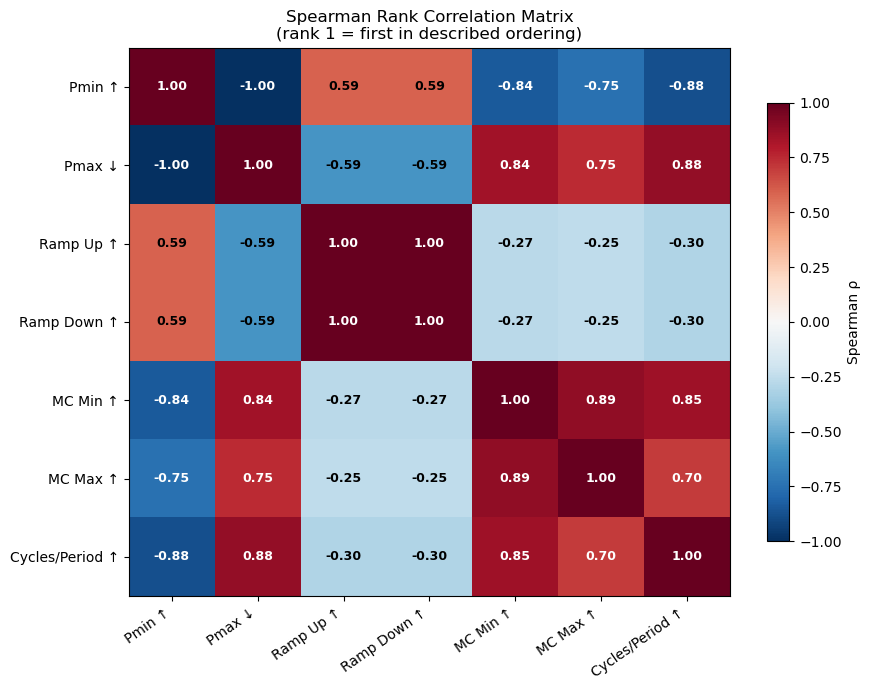

Loading ITables v2.7.1 from the internet... (need help?)


In [20]:
# Rank Correlation Matrix — Spearman correlations between all generator rankings
import matplotlib.pyplot as plt

rank_cols = [
    'rank_min_output_low_high',
    'rank_max_output_high_low',
    'rank_ramp_up_low_high',
    'rank_ramp_down_low_high',
    'rank_mc_min_low_high',
    'rank_mc_max_low_high',
    'rank_cycles_per_period_low_high',
]

short_labels = [
    'Pmin ↑',
    'Pmax ↓',
    'Ramp Up ↑',
    'Ramp Down ↑',
    'MC Min ↑',
    'MC Max ↑',
    'Cycles/Period ↑',
]

# Spearman correlation on the rank columns (ranks of ranks = same result,
# but using Spearman makes the monotonic-relationship intent explicit)
corr = ranks_df[rank_cols].astype(float).corr(method='spearman')
corr.index   = short_labels
corr.columns = short_labels

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)

# Annotate each cell with the correlation value
for i in range(len(short_labels)):
    for j in range(len(short_labels)):
        val = corr.values[i, j]
        text_color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=text_color, fontweight='bold')

fig.colorbar(im, ax=ax, label='Spearman ρ', shrink=0.8)
ax.set_title('Spearman Rank Correlation Matrix\n(rank 1 = first in described ordering)', fontsize=12)
fig.tight_layout()
plt.show()

# ── Also show the numeric table via itable ────────────────────────────────────
show(
    corr.reset_index().rename(columns={'index': ''}),
    caption='Spearman Rank Correlations',
    maxBytes=0,
    columnDefs=[{"className": "dt-center", "targets": "_all"}],
)

In [21]:
# Generator Summary — cost curves + parameter table
import ipywidgets as widgets
from IPython.display import display, Image
from matplotlib.figure import Figure
import numpy as np
import io

with open(THERMAL_PATH) as f:
    thermal_raw = json.load(f)

# ── Cost curve helpers ────────────────────────────────────────────────────────
def get_curve(gen_name):
    pts  = thermal_raw[gen_name]['piecewise_production']
    mw   = [p['mw']   for p in pts]
    cost = [p['cost'] for p in pts]
    mc_mw, mc = [], []
    for i in range(len(pts) - 1):
        dmw   = mw[i+1] - mw[i]
        dcost = cost[i+1] - cost[i]
        if dmw > 0:
            mc_mw.extend([mw[i], mw[i+1]])
            mc.extend([dcost / dmw, dcost / dmw])
    return mw, cost, mc_mw, mc

def _scalar(v):
    if isinstance(v, bool):
        return int(v)
    if isinstance(v, (int, float)):
        return v
    if isinstance(v, list) and v and isinstance(v[0], (int, float)):
        return v[0] if len(v) == 1 else f'{min(v)} – {max(v)}'
    return None

def get_param_table(gen_name):
    rows = []
    for k, v in thermal_raw[gen_name].items():
        if k == 'piecewise_production':
            continue
        s = _scalar(v)
        if s is not None:
            rows.append({'Parameter': k, 'Value': s})
    return pd.DataFrame(rows)

def plot_generator(gen_name):
    gen = thermal_raw[gen_name]
    mw, cost, mc_mw, mc = get_curve(gen_name)
    label = (f"{'Must Run' if gen['must_run'] else 'May Run'}"
             f"  |  Pmin={gen['power_output_minimum']} MW"
             f"  |  Pmax={gen['power_output_maximum']} MW")

    # Use Figure() directly — bypasses pyplot entirely so VS Code's backend
    # never auto-displays the figure outside our controlled display() call
    fig = Figure(figsize=(12, 4))
    fig.suptitle(f'{gen_name} — {label}', fontsize=11)
    ax1, ax2 = fig.subplots(1, 2)

    ax1.plot(mw, cost, 'o-', color='steelblue')
    ax1.set_xlabel('Output (MW)')
    ax1.set_ylabel('Total Cost ($)')
    ax1.set_title('Production Cost Curve')
    ax1.grid(True, alpha=0.3)

    if mc_mw:
        ax2.plot(mc_mw, mc, color='darkorange', linewidth=2)
        ax2.set_xlabel('Output (MW)')
        ax2.set_ylabel('Marginal Cost ($/MW)')
        ax2.set_title('Marginal Cost Curve')
        ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    display(Image(data=buf.read()))

    params_df = get_param_table(gen_name)
    styled = (params_df.style
              .hide(axis='index')
              .set_caption(f'Generator parameters — {gen_name}')
              .set_table_styles([
                  {'selector': 'caption',
                   'props': [('font-weight', 'bold'), ('font-size', '13px'), ('padding-bottom', '6px')]},
                  {'selector': 'th',
                   'props': [('text-align', 'left'), ('padding', '4px 16px'), ('background', '#f0f0f0')]},
                  {'selector': 'td',
                   'props': [('text-align', 'left'), ('padding', '3px 16px')]},
                  {'selector': 'tr:nth-child(even)',
                   'props': [('background', '#fafafa')]},
              ]))
    display(styled)

# ── Widget ────────────────────────────────────────────────────────────────────
gen_names = sorted(thermal_raw.keys())
dropdown = widgets.Dropdown(
    options=gen_names,
    description='Generator:',
    layout=widgets.Layout(width='300px')
)
out = widgets.Output()

def on_change(change):
    with out:
        out.clear_output(wait=True)
        plot_generator(change['new'])

dropdown.observe(on_change, names='value')
display(widgets.VBox([dropdown, out]))

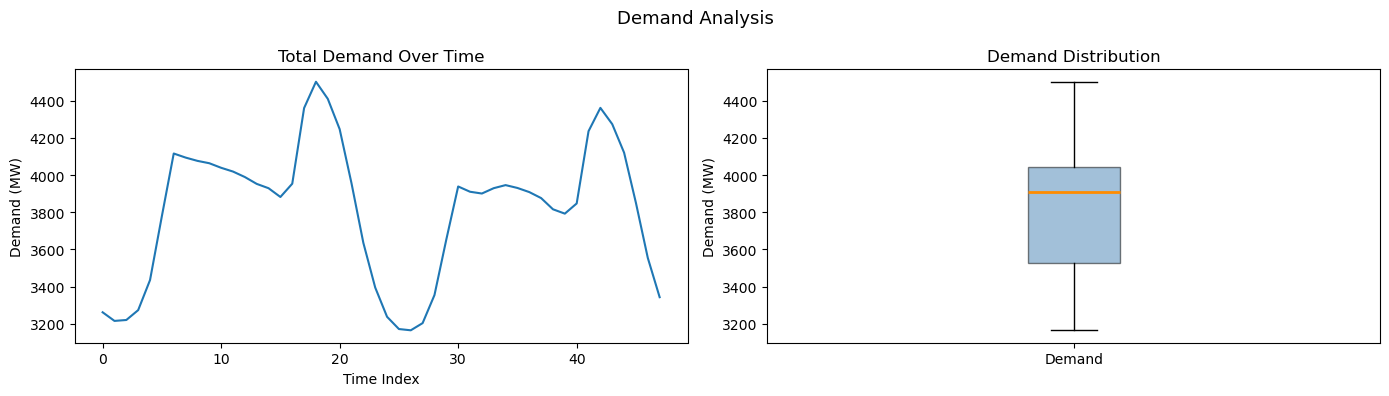

In [22]:
# Demand Analysis — time series and distribution
with open(DEMAND_PATH) as f:
    demand_data = json.load(f)
demand_df = pd.DataFrame(demand_data, columns=['demand'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Demand Analysis', fontsize=13)

demand_df['demand'].plot(ax=ax1)
ax1.set_title('Total Demand Over Time')
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Demand (MW)')

ax2.boxplot(demand_df['demand'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5),
            medianprops=dict(color='darkorange', linewidth=2))
ax2.set_title('Demand Distribution')
ax2.set_ylabel('Demand (MW)')
ax2.set_xticks([1])
ax2.set_xticklabels(['Demand'])

plt.tight_layout()
plt.show()

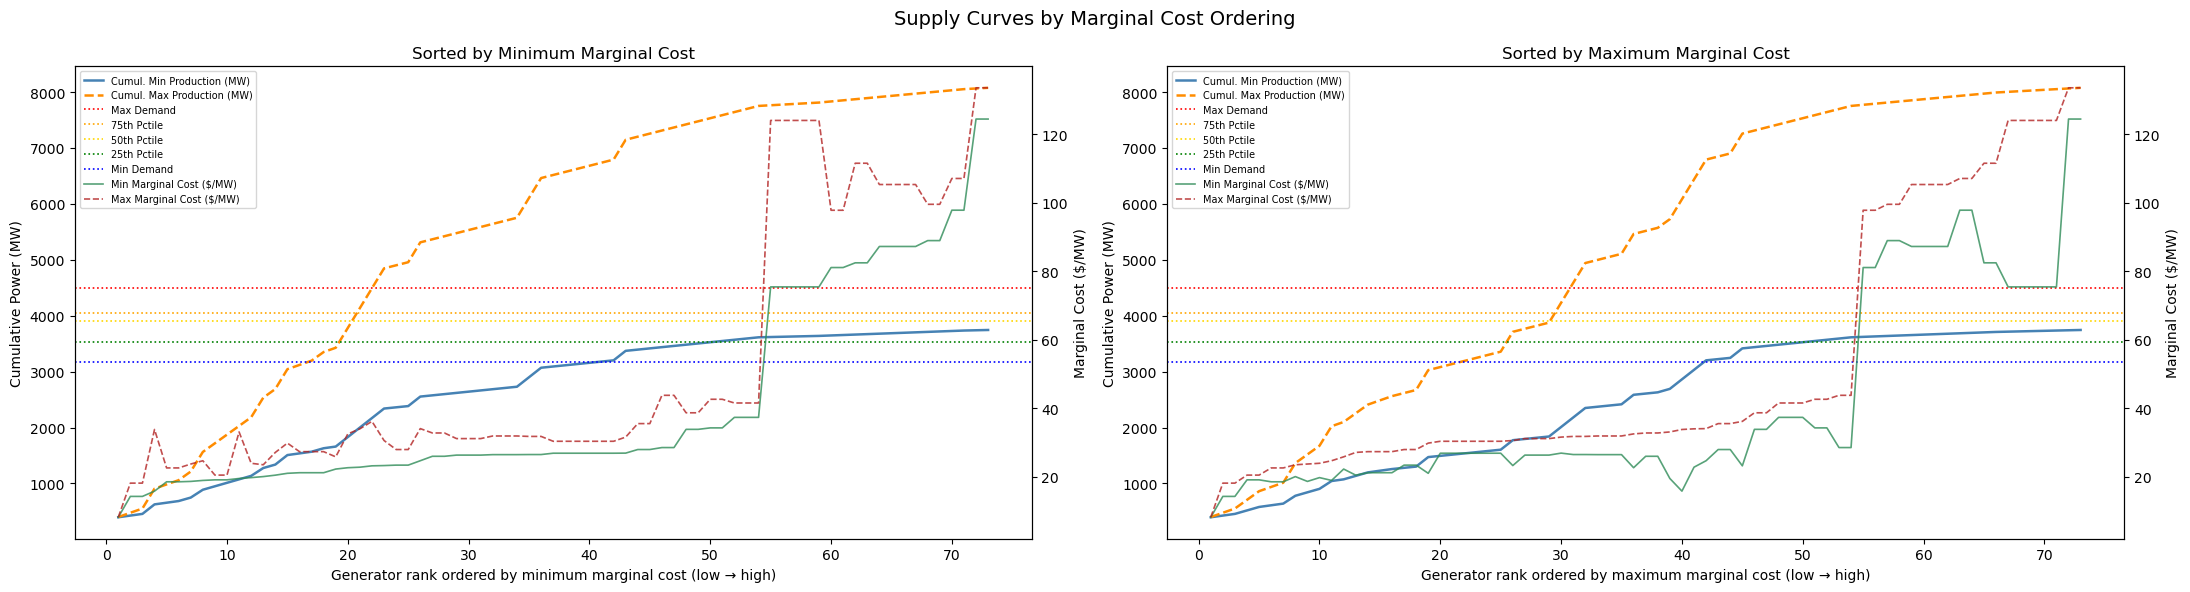

In [23]:
# Supply Curve — sorted by min marginal cost (left) and max marginal cost (right)
# Left y-axis:  cumulative min/max production (MW) + demand reference lines
# Right y-axis: per-generator min/max marginal cost ($/MW), not cumulative

import numpy as np

def get_marginal_cost_range(gen_data):
    pts = gen_data.get('piecewise_production', [])
    if len(pts) < 2:
        return np.nan, np.nan
    mcs = []
    for i in range(len(pts) - 1):
        dmw   = pts[i+1]['mw']   - pts[i]['mw']
        dcost = pts[i+1]['cost'] - pts[i]['cost']
        if dmw > 0:
            mcs.append(dcost / dmw)
    if not mcs:
        return np.nan, np.nan
    return min(mcs), max(mcs)

mc_rows = []
for gen_name, gen_data in thermal_raw.items():
    mc_min, mc_max = get_marginal_cost_range(gen_data)
    mc_rows.append({
        'generator':            gen_name,
        'mc_min':               mc_min,
        'mc_max':               mc_max,
        'power_output_minimum': gen_data['power_output_minimum'],
        'power_output_maximum': gen_data['power_output_maximum'],
    })

mc_df = pd.DataFrame(mc_rows).dropna(subset=['mc_min', 'mc_max'])

def plot_supply_curve(ax1, df_sorted, sort_label):
    x = range(1, len(df_sorted) + 1)

    # Left axis — cumulative MW
    line1, = ax1.plot(x, df_sorted['power_output_minimum'].cumsum(),
                      color='steelblue', linestyle='-',  linewidth=1.8,
                      label='Cumul. Min Production (MW)')
    line2, = ax1.plot(x, df_sorted['power_output_maximum'].cumsum(),
                      color='darkorange', linestyle='--', linewidth=1.8,
                      label='Cumul. Max Production (MW)')
    ax1.set_xlabel(f'Generator rank ordered by {sort_label} (low → high)')
    ax1.set_ylabel('Cumulative Power (MW)')

    # Demand reference lines on left axis
    demand_line_refs = []
    for label, (val, color) in demand_refs.items():
        hl = ax1.axhline(y=val, color=color, linestyle=':', linewidth=1.2, label=label)
        demand_line_refs.append(hl)

    # Right axis — per-generator marginal cost (not cumulative)
    ax2 = ax1.twinx()
    line3, = ax2.plot(x, df_sorted['mc_min'],
                      color='seagreen', linestyle='-',  linewidth=1.2, alpha=0.8,
                      label='Min Marginal Cost ($/MW)')
    line4, = ax2.plot(x, df_sorted['mc_max'],
                      color='firebrick', linestyle='--', linewidth=1.2, alpha=0.8,
                      label='Max Marginal Cost ($/MW)')
    ax2.set_ylabel('Marginal Cost ($/MW)')

    # Combined legend
    lines  = [line1, line2] + demand_line_refs + [line3, line4]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=7, loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.suptitle('Supply Curves by Marginal Cost Ordering', fontsize=14)

plot_supply_curve(axes[0],
                  mc_df.sort_values('mc_min').reset_index(drop=True),
                  'minimum marginal cost')

plot_supply_curve(axes[1],
                  mc_df.sort_values('mc_max').reset_index(drop=True),
                  'maximum marginal cost')

axes[0].set_title('Sorted by Minimum Marginal Cost')
axes[1].set_title('Sorted by Maximum Marginal Cost')

plt.tight_layout()
plt.show()